<a href="https://colab.research.google.com/github/TrishaGanesha/APPClass/blob/main/DANLPProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Perform an exploratory data analysis (EDA) on the 'Reviews.csv' dataset to understand its structure, content, and derive insights into review lengths, word frequencies, and sentiment/rating distribution. The analysis will involve loading the data, performing initial overviews, checking for missing values, and visualizing key aspects of the data.

## Load Dataset

### Subtask:
Load the 'Reviews.csv' file into a pandas DataFrame.


**Reasoning**:
To load the dataset, I need to import the pandas library and then use `pd.read_csv()` to load the 'Reviews.csv' file. After loading, displaying the head will confirm successful loading.



In [1]:
import pandas as pd

df = pd.read_csv('Reviews.csv')
print("Dataset loaded successfully. Displaying the first 5 rows:")
df.head()

Dataset loaded successfully. Displaying the first 5 rows:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## Initial Data Overview

### Subtask:
Display the first few rows, data types, and a statistical summary of the dataset to understand its structure and content.


**Reasoning**:
Displaying the column names, their data types, and descriptive statistics for numerical columns is crucial for an initial data overview. The `info()` method provides a concise summary of the DataFrame, including the number of non-null values in each column, while `describe()` offers statistical insights into numerical features.



In [2]:
print("\nDataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
df.describe()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB

Descriptive Statistics:


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


## Check for Missing Values

### Subtask:
Identify and report any missing values in the dataset, especially focusing on text-related columns.


**Reasoning**:
To identify missing values, I will use the `.isnull()` method to detect nulls and `.sum()` to count them for each column. This will provide a clear overview of missing data.



In [3]:
print("\nMissing Values:")
df.isnull().sum()


Missing Values:


,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


## Analyze Review Lengths

### Subtask:
Calculate the length of each review and visualize the distribution of review lengths using a histogram.


**Reasoning**:
First, I need to create the 'review_length' column by applying `.str.len()` to the 'Text' column of the DataFrame. Then, I will display the descriptive statistics of this new column to understand its distribution.



In [4]:
df['review_length'] = df['Text'].str.len()
print("Descriptive statistics for review lengths:")
print(df['review_length'].describe())

Descriptive statistics for review lengths:
count    568454.000000
mean        436.222083
std         445.339741
min          12.000000
25%         179.000000
50%         302.000000
75%         527.000000
max       21409.000000
Name: review_length, dtype: float64


**Reasoning**:
Now, I will create a histogram to visualize the distribution of review lengths. This will help us understand the spread and common ranges of review lengths.



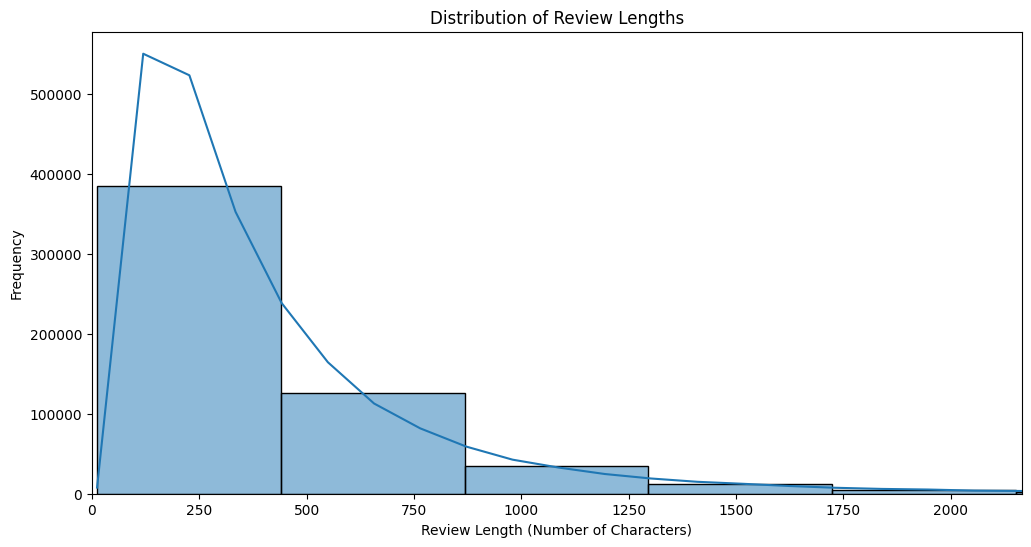

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(df['review_length'], bins=50, kde=True)
plt.title('Distribution of Review Lengths')
plt.xlabel('Review Length (Number of Characters)')
plt.ylabel('Frequency')
plt.xlim(0, df['review_length'].quantile(0.99)) # Limit x-axis to 99th percentile for better visualization
plt.show()


## Analyze Word Frequencies

### Subtask:
Extract and count the most frequent words in the reviews, then visualize them using a bar chart. Stop words should be considered and removed during this process.


**Reasoning**:
The first step is to define a text preprocessing function that converts text to lowercase, removes punctuation, and tokenizes it into words, filtering out non-alphabetic characters. This function will be applied to the 'Text' column.



In [6]:
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Download stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

def preprocess_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers, keep only alphabetic characters and spaces
    words = text.split() # Tokenize into words
    return words

# Apply the preprocessing function to the 'Text' column
df['processed_text'] = df['Text'].apply(preprocess_text)

print("Text preprocessing applied. Displaying the first processed text:")
print(df['processed_text'].head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Text preprocessing applied. Displaying the first processed text:
0    [i, have, bought, several, of, the, vitality, ...
1    [product, arrived, labeled, as, jumbo, salted,...
2    [this, is, a, confection, that, has, been, aro...
3    [if, you, are, looking, for, the, secret, ingr...
4    [great, taffy, at, a, great, price, there, was...
Name: processed_text, dtype: object


**Reasoning**:
Filter out stopwords, count word frequencies, and identify the most common words.



In [7]:
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Download stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

def preprocess_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers, keep only alphabetic characters and spaces
    words = text.split() # Tokenize into words
    return words

# Apply the preprocessing function to the 'Text' column
df['processed_text'] = df['Text'].apply(preprocess_text)

# Get English stopwords
stop_words = set(stopwords.words('english'))

# Filter out stopwords
df['filtered_words'] = df['processed_text'].apply(lambda x: [word for word in x if word not in stop_words])

# Flatten the list of lists into a single list of words
all_words = [word for sublist in df['filtered_words'] for word in sublist]

# Count word frequencies
word_counts = Counter(all_words)

# Get the 20 most common words
most_common_words = word_counts.most_common(20)

print("Most Common Words (after removing stopwords):")
for word, count in most_common_words:
    print(f"{word}: {count}")


Most Common Words (after removing stopwords):
br: 272674
like: 251873
good: 195358
one: 172328
taste: 166606
great: 163575
coffee: 160193
product: 146452
flavor: 142559
tea: 133155
love: 126655
food: 123783
would: 123366
get: 108176
really: 100417
dont: 95580
much: 91909
also: 86108
little: 83197
use: 82764


**Reasoning**:
Now that the most common words and their frequencies have been identified, the next step is to visualize this information using a bar chart to provide a clear and easy-to-understand representation of word frequencies.



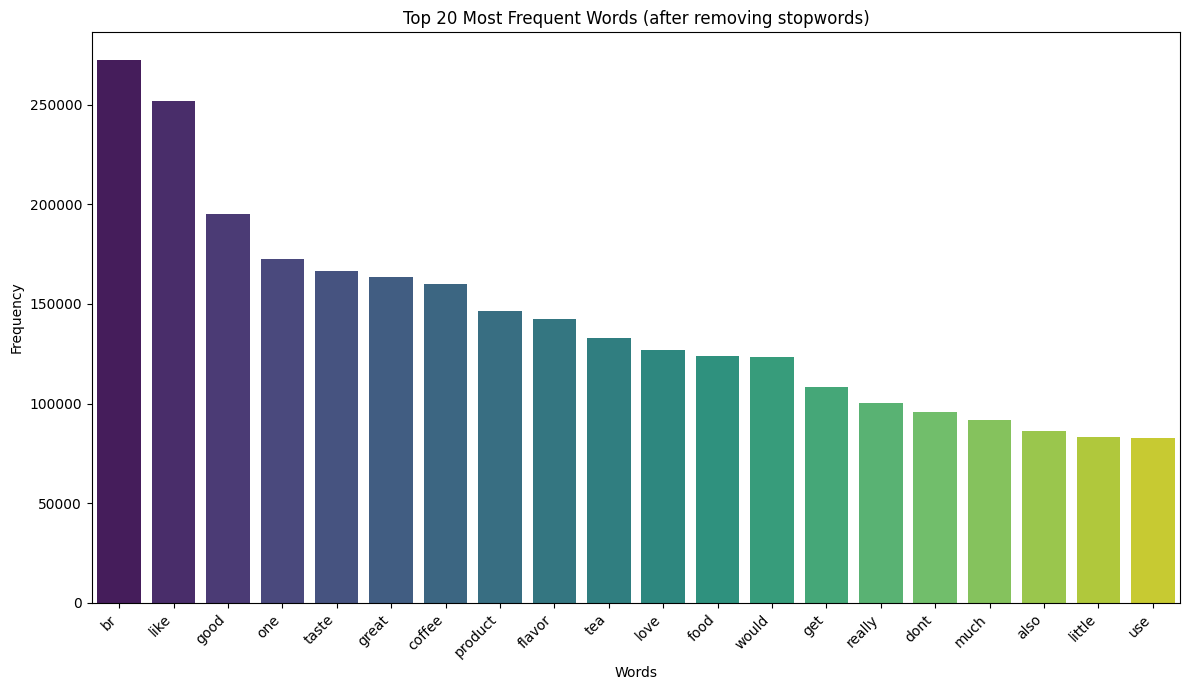

In [9]:
words, counts = zip(*most_common_words)

plt.figure(figsize=(12, 7))
sns.barplot(x=list(words), y=list(counts), hue=list(words), palette='viridis', legend=False)
plt.title('Top 20 Most Frequent Words (after removing stopwords)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Analyze Sentiment/Rating Distribution

### Subtask:
Analyze the distribution of the 'Score' column and visualize it using a bar chart.


**Reasoning**:
The first instruction for this subtask is to calculate the value counts for the 'Score' column. I will use `value_counts()` and `sort_index()` to get the frequencies of each rating and ensure they are in order, then print the result.



In [10]:
score_distribution = df['Score'].value_counts().sort_index()
print("Distribution of Review Scores:")
print(score_distribution)

Distribution of Review Scores:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


**Reasoning**:
Now that the distribution of scores has been calculated, I need to visualize it using a bar chart to clearly show the frequency of each rating.



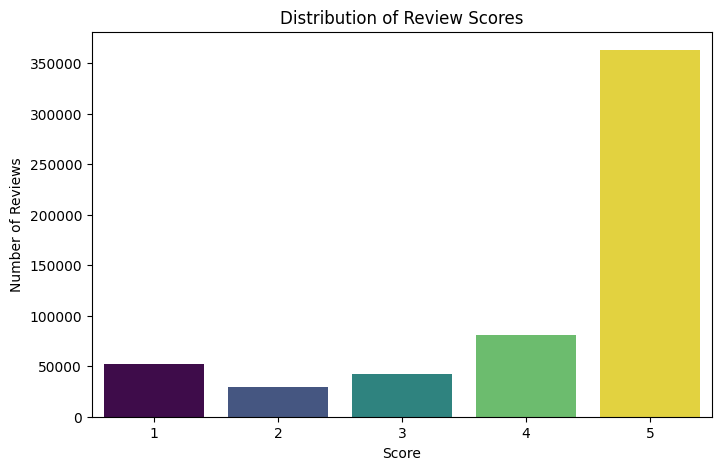

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(x=score_distribution.index, y=score_distribution.values, hue=score_distribution.index, palette='viridis', legend=False)
plt.title('Distribution of Review Scores')
plt.xlabel('Score')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

## Final Task

### Subtask:
Summarize the key findings and insights gained from the exploratory data analysis, highlighting any patterns or anomalies found.


# Task
Perform an exploratory data analysis (EDA) on the 'Reviews.csv' dataset to understand its structure, content, and derive insights into review lengths, word frequencies, and sentiment/rating distribution. The analysis will involve loading the data, performing initial overviews, checking for missing values, and visualizing key aspects of the data.

## Summary:

### Data Analysis Key Findings

*   **Dataset Overview**: The 'Reviews.csv' dataset contains 568,454 entries across 10 columns, including `ProductId`, `UserId`, `ProfileName`, `HelpfulnessNumerator`, `HelpfulnessDenominator`, `Score`, `Time`, `Summary`, and `Text`. Most columns are complete, with minor missing values in `ProfileName` (26 entries) and `Summary` (27 entries), which is a very small fraction of the total dataset.
*   **Review Length Distribution**: The average review length is approximately 436 characters, with a maximum length of 21,409 characters. The distribution is heavily skewed towards shorter reviews, as indicated by the 99th percentile cutoff (around 2000 characters) for visualization, showing a high frequency of reviews between 100 and 500 characters.
*   **Most Frequent Words**: After preprocessing and removing English stopwords, the most frequent words include 'br' (likely line breaks or HTML tags, appearing 272,674 times), 'like' (251,873 times), 'good' (195,358 times), 'one' (172,328 times), and 'taste' (166,606 times). The prevalence of 'br' suggests a need for more robust text cleaning to remove non-textual elements.
*   **Rating Distribution**: The distribution of review scores is highly skewed towards positive ratings. A vast majority of reviews are 5-star ratings (363,122 reviews), followed by 4-star ratings (80,655 reviews). 1-star ratings (52,268 reviews) are more common than 2-star (29,769 reviews) and 3-star ratings (42,640 reviews), indicating a U-shaped distribution where extreme ratings (very good or very bad) are more frequent than neutral ones.

### Insights or Next Steps

*   **Text Cleaning Refinement**: The high frequency of 'br' suggests that further text preprocessing should be implemented to remove HTML tags or other non-alphanumeric characters more effectively before conducting word frequency analysis. This would provide a clearer picture of actual word usage.
*   **Sentiment Analysis Opportunity**: Given the clear distribution of review scores, a valuable next step would be to perform sentiment analysis on the `Text` and `Summary` columns. This could involve training a model to predict the `Score` based on the text content or exploring the sentiment polarity and subjectivity of reviews.
